### Задания 
Первый шаг – загрузить данные и убедиться, что всё считалось правильно: посмотреть на столбцы, размер, наличие пропущенных значений (если есть – удалить). Также изучите типы переменных.
Постройте график распределения количества выпущенных игр по годам и выведите описательные характеристики переменной Year.
На каких платформах произошло больше всего релизов?
Игры каких издателей (Publisher) встречаются в датасете чаще всего?
В каком регионе медианное значение объема продаж игр Nintendo является наибольшим? (Регионы: NA, EU, JP, Other)
Изучите объемы продаж игр Nintendo в Японии с разбивкой жанрам. Посмотрите на медиану, среднее, межквартильный размах.
Визуализируйте динамику изменения объема мировых продаж (Global_Sales) по годам для игр Nintendo следующих жанров: Fighting, Simulation, Platform, Racing, Sports. В какие моменты времени было продано больше всего игр жанра Sports?
Описание данных
Имеются следующие поля:

Rank – место по объему продаж
Name – название игры
Platform – платформа, на которой выпущена игра
Year – год релиза
Genre – жанр
Publisher – издатель
NA_Sales – продажи в Северной Америке, в млн.
EU_Sales – продажи в Европе, в млн.
JP_Sales – продажи в Японии, в млн.
Other_Sales – продажи в остальном мире, в млн.
Global_Sales – продажи по всему миру, в млн.

In [1]:
import pandas as pd

In [3]:
games = pd.read_csv('games.csv')
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [4]:
games.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [5]:
games.shape

(16598, 11)

## Первый шаг – загрузить данные и убедиться, что всё считалось правильно: посмотреть на столбцы, типы данных, размерность, наличие пропущенных значений.

В каком столбце встретилось больше всего пропущенных значений? В качестве ответа укажите их число, после чего удалите строки с пропущенными значениями из датасета. Не забудьте сохранить результат удаления в переменную!



In [8]:
games.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [9]:
games.dropna().shape

(16291, 11)

In [14]:
16598 - 16291 <= 271+58

True

Могло не совпасть, так как в одной строчке могло быть несколько пропусков.

In [15]:
games = games.dropna()

In [16]:
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Задание 2
Выведите описательные характеристики переменной Year и постройте график распределения количества выпущенных игр по годам.



In [17]:
games_year = games.Year
games_year.mean()

np.float64(2006.4055613528942)

In [19]:
games_year.median()

2007.0

In [18]:
games_year.mode()

0    2009.0
Name: Year, dtype: float64

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

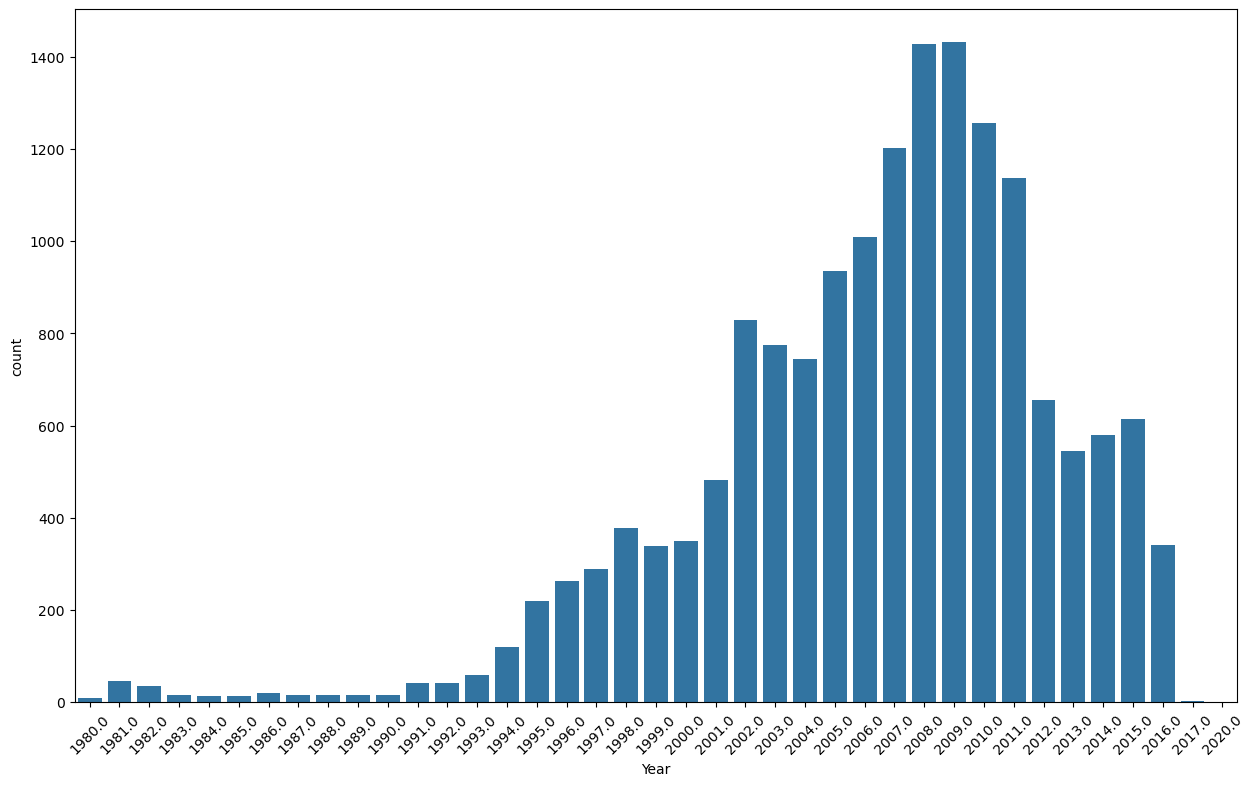

In [29]:
plt.figure(figsize=(15,9))
sns.countplot(data = games, x = games_year)
plt.xticks(rotation = 45 );

## 3 задание
На каких платформах произошло больше всего релизов?

Оставьте названия только тех платформ, частота встречаемости которых составляет более 7%. Значения укажите в порядке убывания частоты встречаемости через запятую с пробелом.



In [57]:
platforms = games.Platform.value_counts(normalize=True)
popular_platforms = platforms[platforms> 0.07].index
print(popular_platforms)

Index(['DS', 'PS2', 'PS3', 'Wii', 'X360', 'PSP', 'PS'], dtype='object', name='Platform')


## 4 задание
Игры каких издателей (Publisher) встречаются в датасете чаще всего?

В качестве ответа укажите наибольшую абсолютную частоту встречаемости.

In [59]:
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,persent_of_platform
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,NaN
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,NaN
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,NaN
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN


In [60]:
games.Publisher.value_counts()

Publisher
Electronic Arts                 1339
Activision                       966
Namco Bandai Games               928
Ubisoft                          918
Konami Digital Entertainment     823
                                ... 
Detn8 Games                        1
Pow                                1
Navarre Corp                       1
MediaQuest                         1
UIG Entertainment                  1
Name: count, Length: 576, dtype: int64

## 4 задание
Сфокусируемся на играх от Nintendo. Посчитайте среднее, медиану и стандартное отклонение по продажам игр данного издателя в разных регионах (NA_sales, EU_sales, JP_sales, Other_sales). 

В каком регионе медианное значение объема продаж является наибольшим?

In [77]:
games.query('Publisher == "Nintendo"').agg({'NA_Sales':['mean', 'median','std'],
                                            'EU_Sales':['mean', 'median','std'],
                                            'JP_Sales':['mean', 'median','std'],
                                            'Other_Sales':['mean', 'median','std']})

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
mean,1.172055,0.601006,0.653721,0.136767
median,0.375000,0.120000,0.280000,0.030000
std,2.989913,1.743953,1.063110,0.464170


## 5 задание 
Теперь посмотрим на продажи Nintendo в Японии по жанрам. Постройте боксплот, где:

по оси x будет расположен жанр игры (Genre)
по оси у – объем продаж в Японии (JP_sales)
Взглянем на получившиеся боксплоты. Что мы можем по ним сказать о данных?



In [78]:
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,persent_of_platform
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,NaN
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,NaN
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,NaN
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN


<Axes: xlabel='Genre', ylabel='JP_Sales'>

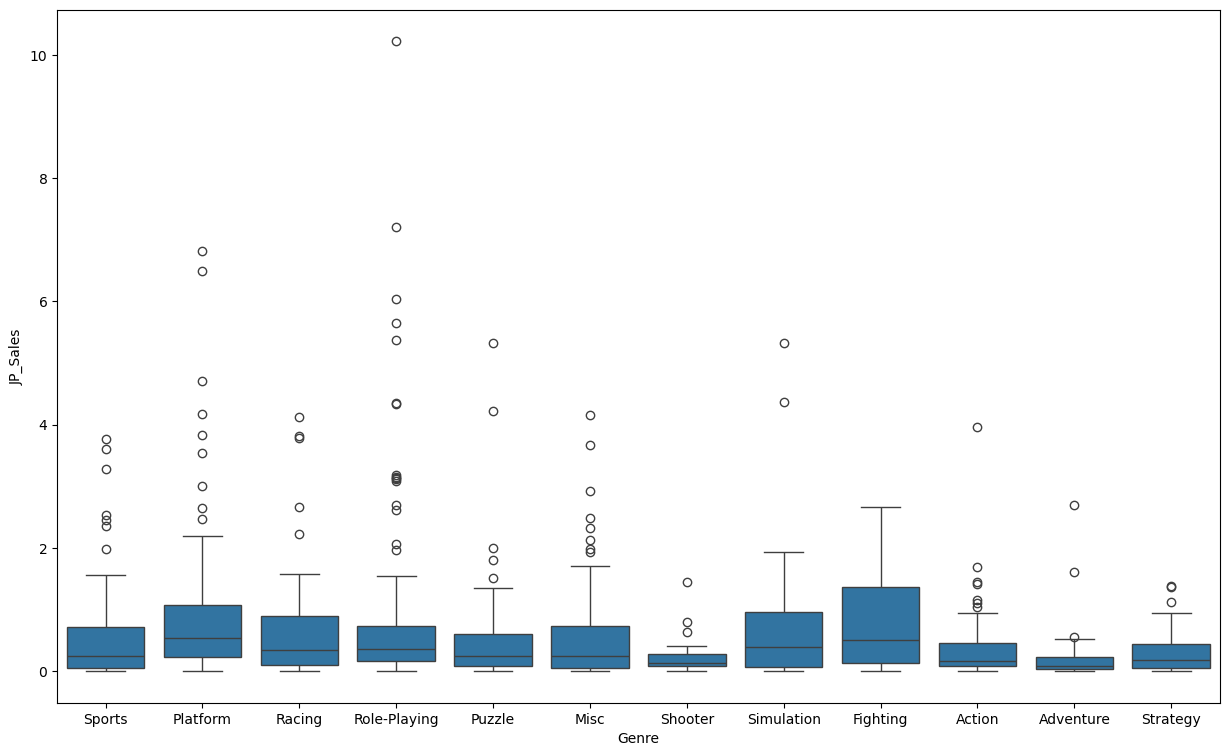

In [80]:
plt.figure(figsize=(15,9))
games_Nintendo = games.query('Publisher == "Nintendo"')
sns.boxplot(data=games_Nintendo, x="Genre", y="JP_Sales")

## 6 задание
Визуализируйте динамику изменения объема мировых продаж (Global_Sales) по годам для игр Nintendo следующих жанров: Fighting, Simulation, Platform, Racing, Sports.

На каком отрезке времени игры жанра Sports были наиболее популярны? Иными словами, выберите наименьший отрезок, который включает в себя несколько крупных пиков. 

In [91]:
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,persent_of_platform
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,NaN
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,NaN
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,NaN
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN


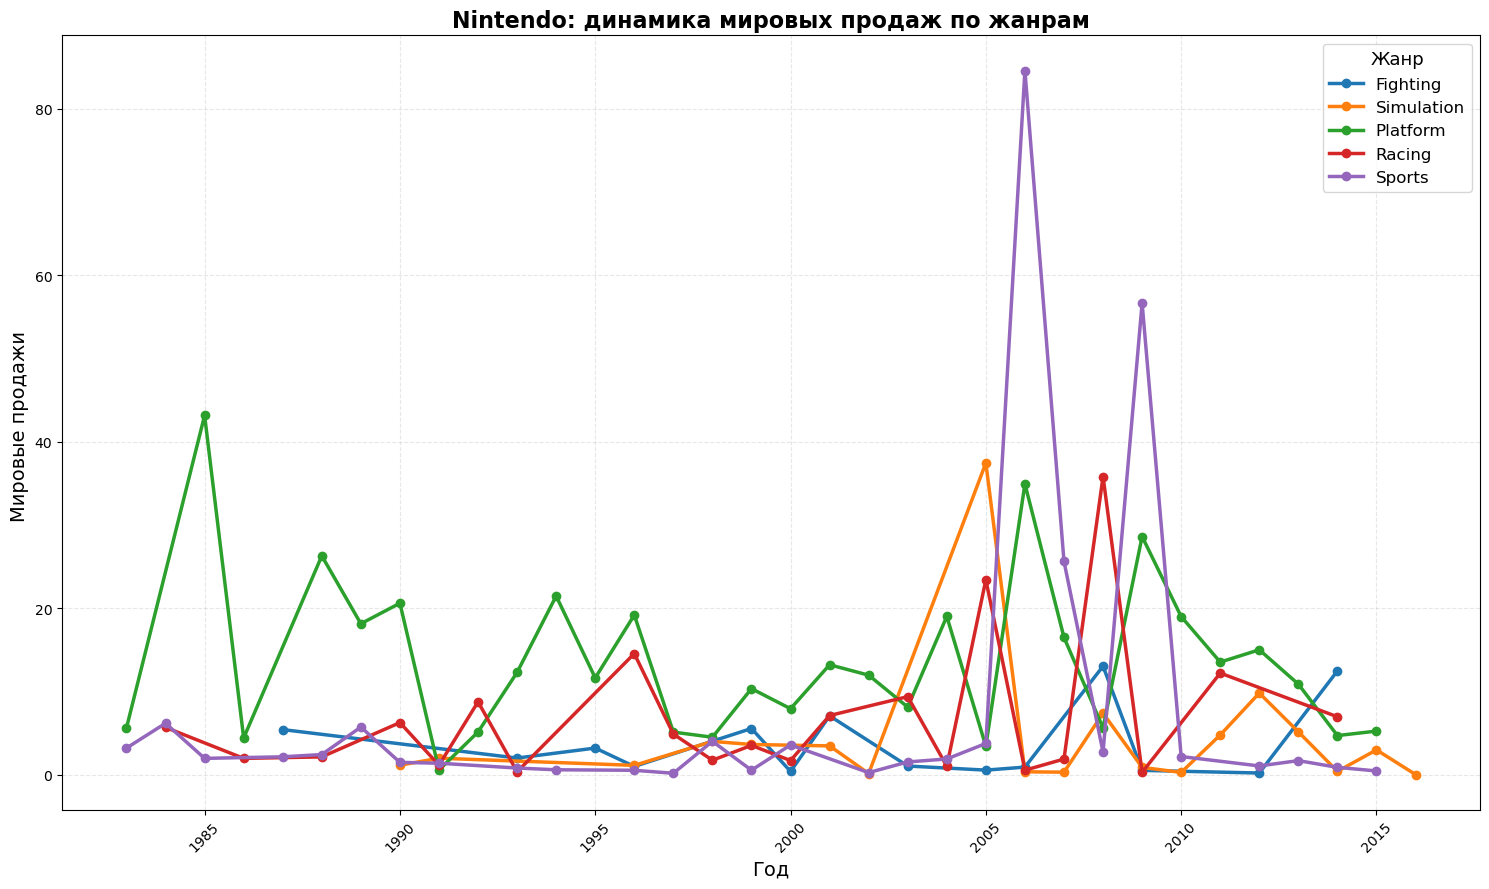

In [115]:
plt.figure(figsize=(15, 9))
our_genre = ['Fighting', 'Simulation', 'Platform', 'Racing', 'Sports']
filtered = games[(games.Publisher == 'Nintendo') & 
                 (games.Genre.isin(our_genre))]
yearly_sales = filtered.groupby(['Year', 'Genre'], as_index=False)['Global_Sales'].sum()

for genre in our_genre:
    data = yearly_sales[yearly_sales['Genre'] == genre]
    plt.plot(data['Year'], data['Global_Sales'], 
             marker='o', linewidth=2.5, label=genre, markersize=6)

plt.xlabel('Год', fontsize=14)
plt.ylabel('Мировые продажи ', fontsize=14)
plt.title('Nintendo: динамика мировых продаж по жанрам', 
          fontsize=16, fontweight='bold')
plt.legend(title='Жанр', fontsize=12, title_fontsize=13)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()